In [2]:
import numpy as np

from desilike.theories.galaxy_clustering import BAOPowerSpectrumTemplate, FlexibleBAOWigglesTracerPowerSpectrumMultipoles, FlexibleBAOWigglesTracerCorrelationFunctionMultipoles
from desilike.observables.galaxy_clustering import TracerPowerSpectrumMultipolesObservable, TracerCorrelationFunctionMultipolesObservable
from desilike.likelihoods import ObservablesGaussianLikelihood
from desilike import setup_logging

setup_logging()

z = 1.
template = BAOPowerSpectrumTemplate(z=z, fiducial='DESI')
theory = FlexibleBAOWigglesTracerPowerSpectrumMultipoles(template=template, broadband='pcs', wiggles='pcs')
params = {'b1': 2.}
# Generate synthetic monopole and quadrupole, between 0.02 and 0.35 h/Mpc
observable = TracerPowerSpectrumMultipolesObservable(data=params, covariance=None,
                                                     klim={0: [0.005, 0.35, 0.005], 2: [0.005, 0.35, 0.005]},
                                                     theory=theory)

observable.init.update(data=observable.flatdata)  # fix the data vector

from desilike.observables.galaxy_clustering import BoxFootprint, ObservablesCovarianceMatrix

footprint = BoxFootprint(volume=5e9, nbar=1e-4)  # box with volume of 5 (Gpc/h)^3 and density of 1e-4 (h/Mpc)^3
covariance = ObservablesCovarianceMatrix(observables=[observable], footprints=[footprint])
likelihood = ObservablesGaussianLikelihood(observables=[observable], covariance=covariance(**params))

PipelineError: Error in method initialize of <desilike.observables.galaxy_clustering.power_spectrum.TracerPowerSpectrumMultipolesObservable object at 0x7b1338162530>

PipelineError: Error in method initialize of <desilike.theories.galaxy_clustering.bao.FlexibleBAOWigglesTracerPowerSpectrumMultipoles object at 0x74d2797602e0>

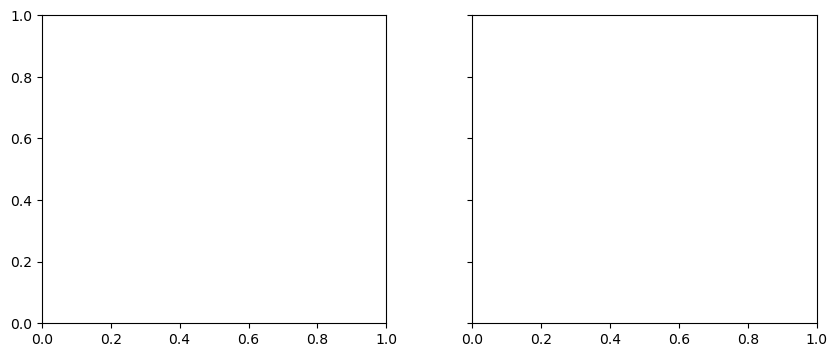

In [5]:
from matplotlib import pyplot as plt

fig, lax = plt.subplots(1, 2, sharex=False, sharey=True, figsize=(10, 4), squeeze=True)
fig.subplots_adjust(wspace=0.25)
th = FlexibleBAOWigglesTracerPowerSpectrumMultipoles(ells=(0, 2), broadband='pcs', wiggles='pcs')
for iax, mode in enumerate(['additive', 'multiplicative']):
    ax = lax[iax]
    for ill, ell in enumerate(th.ells):
        names = th.varied_params.names(basename='{}l{:d}_*'.format(mode[0], ell))
        cmap = plt.get_cmap('jet', len(names))
        for iname, name in enumerate(names):
            pk = th(**{name: 1.})
            ax.plot(th.k, th.k * pk[ill], color=cmap(iname / len(names)))
            pk = th(**{name: 0.})
        ax.plot(th.k, th.k * pk[ill], color='k')
    ax.grid(True)
    ax.set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
    ax.set_ylabel(r'$k P_{\ell}(k)$ [$(\mathrm{Mpc}/h)^{2}$]')
    ax.set_title(mode)
plt.show()